<a href="https://colab.research.google.com/github/dnb1010/-Breast-Cancer-Project-/blob/main/Email_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd '/content/drive/MyDrive/Data/'

/content/drive/MyDrive/Data


In [ ]:
!ls

completeSpamAssassin.csv


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for text processing and handling text data
import re
import nltk
nltk.download('stopwords')
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Model training
from sklearn.naive_bayes import BernoulliNB

# Model evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score, precision_score

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Load dataset
df = pd.read_csv('completeSpamAssassin.csv')
df.head()

,Unnamed: 0,Body,Label
0,0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,3,##############################################...,1
4,4,I thought you might like these:\n1) Slim Down ...,1


In [ ]:
# How big is the data?
df.shape

(6046, 3)

In [ ]:
# What is the data type of cols?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6046 entries, 0 to 6045
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6046 non-null   int64 
 1   Body        6045 non-null   object
 2   Label       6046 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 141.8+ KB


In [ ]:
# Are there any missing values?
df.isnull().sum()

,0
Unnamed: 0,0
Body,1
Label,0


In [ ]:
# Are there any duplicate values?
df.duplicated().sum()

np.int64(0)

In [ ]:
# Dropping null values
df.dropna(inplace=True)

In [ ]:
# Dropping redudant column
df.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
df.head()

,Body,Label
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,##############################################...,1
4,I thought you might like these:\n1) Slim Down ...,1


For the purpose of data exploration, I will create some new features:
* no_char: number of characters in the email
* no_word: number of words in the emai
* no_sent: number of sentences in the email

In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Adding a column of numbers of characters, words and sentences in emails
df['no_char'] = df['Body'].apply(len)
df['no_words'] = df['Body'].apply(lambda x:len(nltk.word_tokenize(x)))
df['no_sent'] = df['Body'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,Body,Label,no_char,no_words,no_sent
0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1,1111,191,12
1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,753,139,5
2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1,610,113,4
3,##############################################...,1,2863,690,35
4,I thought you might like these:\n1) Slim Down ...,1,641,108,4


In [ ]:
df.describe()

,Label,no_char,no_words,no_sent
count,6045.000000,6045.000000,6045.000000,6045.000000
mean,0.313482,1758.272787,328.882878,11.714971
std,0.463947,4940.284032,766.591788,26.649811
min,0.000000,1.000000,0.000000,0.000000
25%,0.000000,439.000000,82.000000,3.000000
50%,0.000000,899.000000,173.000000,6.000000
75%,1.000000,1624.000000,318.000000,11.000000
max,1.000000,194978.000000,18571.000000,808.000000


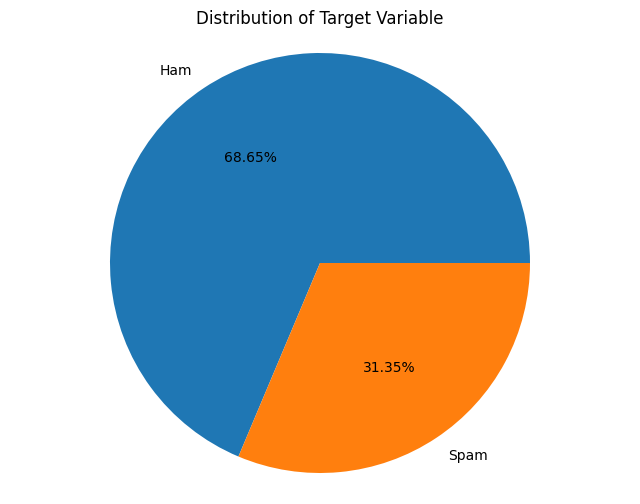

In [ ]:
# The distriction of target variable
plt.figure(figsize=(8,6))
plt.pie(df['Label'].value_counts(), labels=['Ham', 'Spam'], autopct='%1.2f%%')
plt.axis('equal')
plt.title('Distribution of Target Variable')
plt.show()

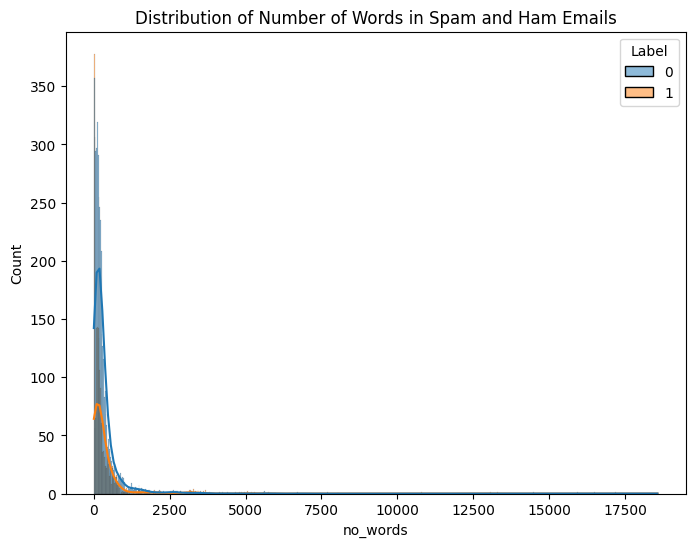

In [ ]:
# The distriction of number of words in spam and ham email
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='no_words', hue='Label', kde=True)
plt.title('Distribution of Number of Words in Spam and Ham Emails')
plt.show()

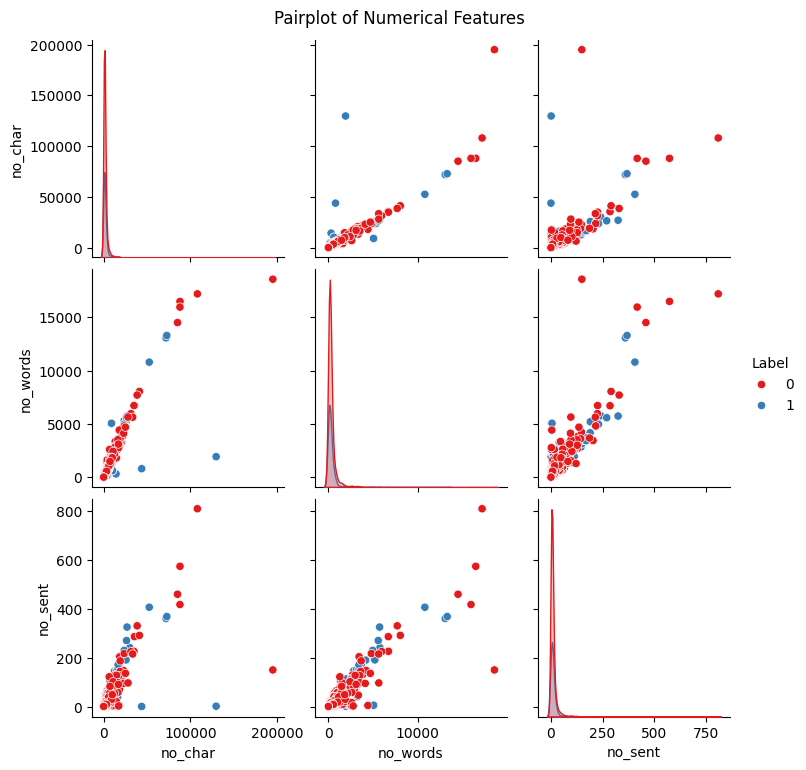

In [ ]:
g = sns.pairplot(df, hue='Label', palette='Set1')
g.fig.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

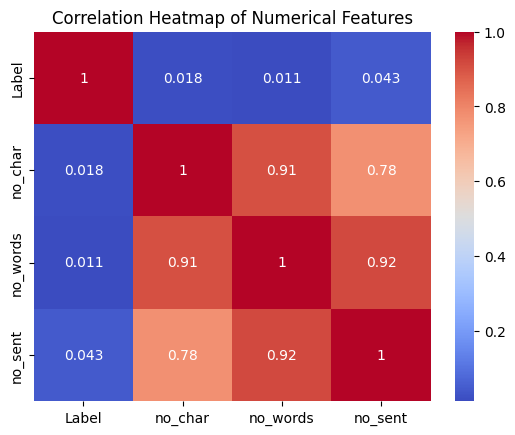

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

Text Processing. FOr this problem, I create a function which performs follwing steps:
1. Text Lowercase
2. Word Tokenize
3. Remove Special Charaters
4. Remove Stopwords
5. Remove Punctuation
6. Stemming

In [ ]:
def text_processing(text):
    # Convert text to lowercase
    text = text.lower()

    # Word Tokenize
    text= nltk.word_tokenize(text)

    # Remve special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    text = y[:]
    y.clear()

    # Remove stopwords and punctuation marks
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Stemming
    stemmer = PorterStemmer()
    for i in text:
        y.append(stemmer.stem(i))

    return " ".join(y)

In [ ]:
# Applying function to text
df['clean_text'] = df['Body'].apply(text_processing)

In [ ]:
import joblib

In [ ]:
# Changing text data to number and fit vectorizer in train set
vectorizer = TfidfVectorizer()
joblib.dump(vectorizer, '/content/drive/MyDrive/Data/vectorizer.pkl')
# Setting up features and target as X and y
X = vectorizer.fit_transform(df['clean_text']).toarray()
y = df['Label']

In [ ]:
# Splitting the testing and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred = bnb.predict(X_test)
joblib.dump(bnb, '/content/drive/MyDrive/Data/model.pkl')

['/content/drive/MyDrive/Data/model.pkl']

In [ ]:
def train_classifier(X_train, y_train, X_test, y_test):
   accuracy = accuracy_score(y_test, y_pred)
   precision_score = precision_score(y_test, y_pred)
   recall_score = recall_score(y_test, y_pred)
   f1_score = f1_score(y_test, y_pred)
   return accuracy, precision_score, recall_score, f1_score

In [ ]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")

Accuracy: 0.9065343258891646
Precision: 0.9865319865319865
Recall: 0.7288557213930348


Correct:  1096
Wrong:  113


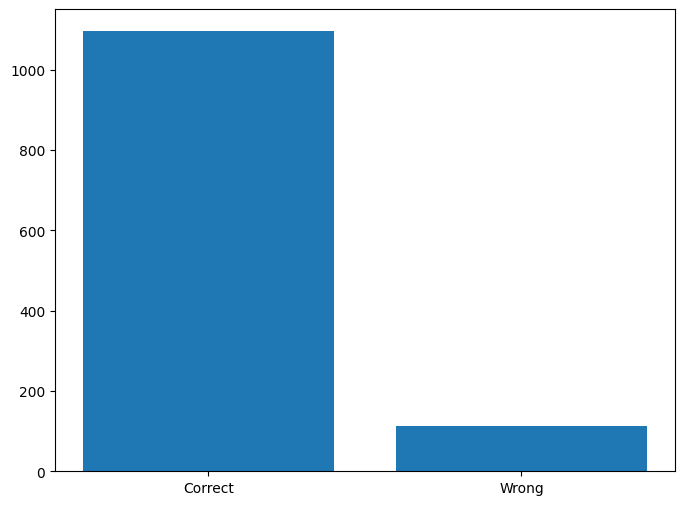

In [ ]:
# Evaluate the number of correct and wrong testcase
correct = 0
wrong = 0
for i in range(len(y_test)):
  if y_pred[i] == y_test.iloc[i]:
    correct += 1
  else:
    wrong += 1
print("Correct: ", correct)
print("Wrong: ", wrong)
fix, ax = plt.subplots(figsize=(8,6))
ax.bar(['Correct', 'Wrong'], [correct, wrong])
plt.show()

In [ ]:
def predict_email(text):
  text = text_processing(text)
  text = vectorizer.transform([text]).toarray()
  prediction = bnb.predict(text)
  return "SPAM" if prediction[0] == 1 else "HAM"

In [ ]:
email_test = """Congratulations! You win prize!"""
print("Result: ", predict_email(email_test))

Result:  HAM
